# Interactive One-Stage Convolutional Network

This notebook demonstrates a single-stage convolutional network where one can interactively choose an input image, select different convolution kernels, and adjust parameters like kernel size, dilation, stride, and padding.

The output of the convolution is displayed live with side-by-side comaprison of two different setups.

In [ ]:
import numpy as np
import pandas as pd
import struct
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

# Ensure TensorFlow uses eager execution for easier debugging if needed
tf.config.run_functions_eagerly(True)

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Define Convolution Kernels

Pre-defined 3x3 and 5x5 kernels set as dictionaries for various image processing effects.

In [ ]:
kernels3 = {
    'Identity': np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1],
                                            [-1,  8, -1],
                                            [-1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1,  0],
                        [-1,  1,  1],
                        [ 0,  1,  2]], dtype=np.float32)
}

kernels5 = {
    'Identity': np.array([[0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 1, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, 8, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0],
                         [-1, -1, 5, -1, -1],
                         [ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1, -1, 0, 0],
                        [-1, -1, 0, 0, 0],
                        [-1, 0, 1, 0,  1],
                        [ 0, 0, 0, 1, 1],
                        [ 0, 0, 1, 1, 2]], dtype=np.float32)
}

kernel_types = list(kernels3.keys())

print("Convolution kernels defined.")

Convolution kernels defined.


### 3. Convolution Function and Interactive Controls

Use the widgets below to select a kernel and adjust convolution parameters. The original and convolved images will be displayed.

In [ ]:
def perform_single_convolution(image_data, kernel_type, kernel_size, dilations, strides, padding_size):
    if image_data is None:
        print("No image selected or image failed to load.")
        return None

    # Reshape image for TensorFlow: [batch, height, width, channels]
    image_tensor = tf.constant(image_data[tf.newaxis, :, :, tf.newaxis], dtype=tf.float32)

    # Get the selected kernel
    kernel = kernels3[kernel_type] if kernel_size == 3 else kernels5[kernel_type]

    # Reshape kernel for TensorFlow: [height, width, in_channels, out_channels]
    # For grayscale images, in_channels = 1, out_channels = 1
    kernel_tensor = tf.constant(kernel[:, :, tf.newaxis, tf.newaxis], dtype=tf.float32)

    # Padding configuration
    # 'VALID' means no padding, 'SAME' means padding to ensure output size is same as input (stride=1)

    if padding_size > 0:
        # Pad the image manually
        paddings = tf.constant([[0, 0], [padding_size, padding_size], [padding_size, padding_size], [0, 0]])
        image_tensor = tf.pad(image_tensor, paddings, "CONSTANT")
        padding_mode = 'VALID' # After manual padding, use VALID convolution
    else:
        padding_mode = 'VALID'

    # Apply convolution
    try:
        output_tensor = tf.nn.conv2d(
            input=image_tensor,
            filters=kernel_tensor,
            strides=[1, strides, strides, 1], # strides in height and width
            padding=padding_mode,
            dilations=[1, dilations, dilations, 1] # dilations in height and width
        )
        return output_tensor[0, :, :, 0].numpy() # Remove batch and channel dims
    except Exception as err:
        print(f"Error during convolution: {err}")
        return None


# Create widgets for interaction - Setup 1
kernel_type_widget_1 = widgets.Dropdown(
    options=kernel_types,
    value='Identity',
    description='Kernel Type 1:'
)
kernel_size_widget_1 = widgets.RadioButtons(
    options=[3 , 5],
    description='Kernel Size 1 (N x N):'
)
dilations_widget_1 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Dilations 1:'
)
strides_widget_1 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Strides 1:'
)
padding_widget_1 = widgets.IntSlider(
    value=0,
    min=0,
    max=5,
    step=1,
    description='Padding Size 1:'
)

# Create widgets for interaction - Setup 2
kernel_type_widget_2 = widgets.Dropdown(
    options=kernel_types,
    value='Edge Detection (Laplacian)', # Default to a different kernel for comparison
    description='Kernel Type 2:'
)
kernel_size_widget_2 = widgets.RadioButtons(
    options=[3 , 5],
    description='Kernel Size 2 (N x N):'
)
dilations_widget_2 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Dilations 2:'
)
strides_widget_2 = widgets.IntSlider(
    value=1,
    min=1,
    max=5,
    step=1,
    description='Strides 2:'
)
padding_widget_2 = widgets.IntSlider(
    value=0,
    min=0,
    max=5,
    step=1,
    description='Padding Size 2:'
)

use of MNIST data set from Kaggle


https://www.kaggle.com/datasets/hojjatk/mnist-dataset?resource=download&select=t10k-images.idx3-ubyte


other option CIFAR-10 or CIFAR-100

In [ ]:
# Path to the dataset file
file_path = '/content/train-images-idx3-ubyte'

try:
    with open(file_path, 'rb') as f:
        # Read the magic number, number of images, rows, and columns
        magic, num_images, num_rows, num_cols = struct.unpack('>IIII', f.read(16))

        # Ensure the magic number is correct for image files (0x00000803)
        if magic != 2051:
            raise ValueError(f"Invalid magic number: {magic}. Expected 2051 for image file.")

        # Read the image data
        # Each pixel is a byte (unsigned char, 'B'), so total bytes = num_images * num_rows * num_cols
        image_data = np.frombuffer(f.read(), dtype=np.uint8)

    # Reshape the data into individual images
    # The original data is flat, reshape to (num_images, num_rows, num_cols)
    images = image_data.reshape(num_images, num_rows, num_cols)

    print(f"Successfully loaded {num_images} images.")
    print(f"Image dimensions: {num_rows}x{num_cols} pixels.")

    # Flatten each image into a single row to create a DataFrame
    # Each row will be an image, and each column a pixel
    flattened_images = images.reshape(num_images, num_rows * num_cols)

    # Create a pandas DataFrame
    # We don't need specific column names for stats, but we can generate them if needed
    df = pd.DataFrame(flattened_images)

    print("\nDataFrame Head:")
    display(df.head())

    print("\nDataFrame Statistics:")
    display(df.describe())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded or in the correct directory.")
except ValueError as e:
    print(f"Data parsing error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully loaded 60000 images.
Image dimensions: 28x28 pixels.

DataFrame Head:


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



DataFrame Statistics:


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


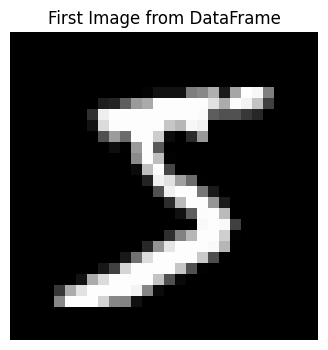

In [ ]:
# Get the first image (first row) from the DataFrame
first_image_flat = df.iloc[0].values

# Assuming images are 28x28 pixels, reshape the flattened image
image_dimension = int(np.sqrt(len(first_image_flat))) # Should be 28
first_image_reshaped = first_image_flat.reshape(image_dimension, image_dimension)

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(first_image_reshaped, cmap='gray')
plt.title('First Image from DataFrame')
plt.axis('off')
plt.show()

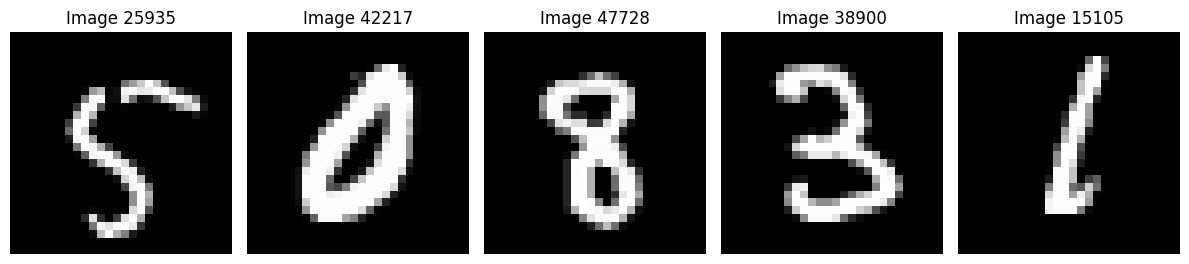

In [ ]:
# Get 10 random indices from the DataFrame
random_indices = np.random.choice(df.index, size=5, replace=False)

# Assuming image_dimension (28) is already defined from previous cells
# If not, you might need to re-derive it: image_dimension = int(np.sqrt(df.shape[1]))
image_dimension = 28 # Given the previous context, this should be 28

plt.figure(figsize=(12, 5)) # Adjust figure size for 10 images
for i, index in enumerate(random_indices):
    # Get the flattened image data for the current random index
    random_image_flat = df.loc[index].values

    # Reshape the flattened image to its original 28x28 dimensions
    random_image_reshaped = random_image_flat.reshape(image_dimension, image_dimension)

    # Plot the image in a subplot
    plt.subplot(2, 5, i + 1) # 2 rows, 5 columns
    plt.imshow(random_image_reshaped, cmap='gray')
    plt.title(f"Image {index}")
    plt.axis('off')

plt.tight_layout() # Adjust layout to prevent overlapping titles/images
plt.show()

In [ ]:
# Ensure `df` (DataFrame of MNIST images) and `image_dimension` (28) are available.
# Also, `kernels3`, `kernels5`, and `perform_single_convolution` are expected to be available globally
# from previously executed cells.

# --- Step 1: Generate 5 random images from the DataFrame and prepare selection widget ---
num_random_images = 5
# Select 5 unique random indices from the DataFrame
random_indices_for_selection = np.random.choice(df.index, size=num_random_images, replace=False)

random_image_data_dict = {}
random_image_labels = []
image_dimension = 28 # MNIST images are 28x28 pixels

for i, index in enumerate(random_indices_for_selection):
    image_flat = df.loc[index].values
    # Reshape the flattened image and normalize pixel values to [0, 1]
    image_reshaped = image_flat.reshape(image_dimension, image_dimension).astype(np.float32) / 255.0
    label = f"Random Image {i+1} (idx: {index})"
    random_image_data_dict[label] = image_reshaped # Store image data with label as key
    random_image_labels.append(label) # Store just the labels for the widget options

# Create a RadioButtons widget to allow the user to select one of these random images
image_choice_widget = widgets.RadioButtons(
    options=random_image_labels, # Pass only the labels as options
    description='Choose Image:',
    disabled=False,
    value=random_image_labels[0] # Set initial value to the label of the first random image
)

# --- Step 2: Redefine the interactive convolution function ---

def interactive_convolution(
    image_input_label, # The selected image label (string) will be passed here
    kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1,
    kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
):
    clear_output(wait=True) # Clear previous output in the output area

    # Retrieve the actual image data using the selected label
    image_input = random_image_data_dict.get(image_input_label)

    if image_input is None:
        print("No image selected for display. Please choose an image.")
        return

    # Perform first convolution using the provided image_input
    output_image_data_1 = perform_single_convolution(
        image_input, kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1
    )
    output_shape_1 = output_image_data_1.shape if output_image_data_1 is not None else "N/A"

    dilated_kernel_size_1 = kernel_size_1 + (kernel_size_1 - 1) * (dilations_1 - 1)
    rf_1 = dilated_kernel_size_1

    # Perform second convolution using the provided image_input
    output_image_data_2 = perform_single_convolution(
        image_input, kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
    )
    output_shape_2 = output_image_data_2.shape if output_image_data_2 is not None else "N/A"

    dilated_kernel_size_2 = kernel_size_2 + (kernel_size_2 - 1) * (dilations_2 - 1)
    rf_2 = dilated_kernel_size_2

    # Display results using matplotlib
    plt.figure(figsize=(14, 6))

    # Original Image subplot
    plt.subplot(1, 3, 1)
    plt.title('Original Image')
    plt.imshow(image_input, cmap='gray') # Display the selected random image
    plt.axis('off')

    # Convolved Output 1 subplot
    plt.subplot(1, 3, 2)
    plt.title(f'Convolved Output 1 ({kernel_type_1})')
    if output_image_data_1 is not None:
        plt.imshow(output_image_data_1, cmap='gray')
    plt.axis('off')

    # Convolved Output 2 subplot
    plt.subplot(1, 3, 3)
    plt.title(f'Convolved Output 2 ({kernel_type_2})')
    if output_image_data_2 is not None:
        plt.imshow(output_image_data_2, cmap='gray')
    plt.axis('off')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

    # Print the output details as text below the plot
    print("\n--- Convolution Setup 1 Details ---")
    print(f"  Output Size: {output_shape_1}")
    print(f"  RF: {rf_1}x{rf_1}")

    print("\n--- Convolution Setup 2 Details ---")
    print(f"  Output Size: {output_shape_2}")
    print(f"  RF: {rf_2}x{rf_2}")


# --- Step 3: Create the new UI structure and interactive output ---
# Reuse the existing convolution parameter widgets from cell `ac905cd3`.
# These are `kernel_type_widget_1`, `kernel_size_widget_1`, `dilations_widget_1`, `strides_widget_1`, `padding_widget_1`,
# and their '_2' counterparts.

interactive_ui = widgets.VBox([
    widgets.Label(value='Select an image from 5 random MNIST digits:'),
    image_choice_widget, # The new random image selection widget
    widgets.HBox([
        widgets.VBox([
            widgets.Label(value='Convolution Setup 1:'),
            kernel_type_widget_1,
            kernel_size_widget_1,
            dilations_widget_1,
            strides_widget_1,
            padding_widget_1
        ]),
        widgets.VBox([
            widgets.Label(value='Convolution Setup 2:'),
            kernel_type_widget_2,
            kernel_size_widget_2,
            dilations_widget_2,
            strides_widget_2,
            padding_widget_2
        ])
    ])
])

# Create a new interactive output link, connecting the new image selector
# and all existing parameter widgets to the `interactive_convolution_v2` function.
out = widgets.interactive_output(interactive_convolution, {
    'image_input_label': image_choice_widget, # Link the new image selector here
    'kernel_type_1': kernel_type_widget_1,
    'kernel_size_1': kernel_size_widget_1,
    'dilations_1': dilations_widget_1,
    'strides_1': strides_widget_1,
    'padding_size_1': padding_widget_1,
    'kernel_type_2': kernel_type_widget_2,
    'kernel_size_2': kernel_size_widget_2,
    'dilations_2': dilations_widget_2,
    'strides_2': strides_widget_2, # Corrected from strides_2 to strides_widget_2
    'padding_size_2': padding_widget_2
})

# --- Step 4: Display the new UI and output ---
print("Interactive Convolution Dashboard (with random MNIST image selection):")
display(interactive_ui, out)


Interactive Convolution Dashboard (with random MNIST image selection):


Output()

streamlit + tunnel

In [ ]:
!pip install -q streamlit
!npm install -q -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
changed 22 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋

In [ ]:
%%writefile streamlit_app.py
import streamlit as st
import numpy as np
import pandas as pd
import struct
import tensorflow as tf
import matplotlib.pyplot as plt

st.set_page_config(layout="wide")

st.title("Interactive One-Stage Convolutional Network")
st.markdown("This app demonstrates a single-stage convolutional network where you can interactively choose an input image, select different convolution kernels, and adjust parameters like kernel size, dilation, stride, and padding.")
st.markdown("The output of the convolution is displayed live with side-by-side comparison of two different setups.")

st.header("1. Load MNIST Data")
file_path = '/content/train-images-idx3-ubyte'

@st.cache_data
def load_mnist_data(path):
    try:
        with open(path, 'rb') as f:
            magic, num_images, num_rows, num_cols = struct.unpack('>IIII', f.read(16))
            if magic != 2051:
                st.error(f"Invalid magic number: {magic}. Expected 2051 for image file.")
                return None
            image_data = np.frombuffer(f.read(), dtype=np.uint8)
        images = image_data.reshape(num_images, num_rows, num_cols)
        flattened_images = images.reshape(num_images, num_rows * num_cols)
        df = pd.DataFrame(flattened_images)
        return df, num_rows
    except FileNotFoundError:
        st.error(f"Error: The file '{path}' was not found. Please ensure it's uploaded or in the correct directory.")
        return None, None
    except Exception as e:
        st.error(f"An unexpected error occurred during data loading: {e}")
        return None, None

df, image_dimension = load_mnist_data(file_path)

if df is not None:
    st.success(f"Successfully loaded {len(df)} MNIST images ({image_dimension}x{image_dimension} pixels).")
    st.write("DataFrame Head:", df.head())


st.header("2. Define Convolution Kernels")
kernels3 = {
    'Identity': np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1],
                                            [-1,  8, -1],
                                            [-1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1,  0],
                        [-1,  1,  1],
                        [ 0,  1,  2]], dtype=np.float32)
}

kernels5 = {
    'Identity': np.array([[0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 1, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, 8, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0],
                         [-1, -1, 5, -1, -1],
                         [ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1, -1, 0, 0],
                        [-1, -1, 0, 0, 0],
                        [-1, 0, 1, 0,  1],
                        [ 0, 0, 0, 1, 1],
                        [ 0, 0, 1, 1, 2]], dtype=np.float32)
}
kernel_types = list(kernels3.keys())


Writing streamlit_app.py


In [ ]:
%%writefile -a streamlit_app.py

st.header("3. Convolution Function and Interactive Controls")

def perform_single_convolution(image_data, kernel_type, kernel_size, dilations, strides, padding_size):
    if image_data is None:
        return None

    image_tensor = tf.constant(image_data[tf.newaxis, :, :, tf.newaxis], dtype=tf.float32)

    kernel = kernels3[kernel_type] if kernel_size == 3 else kernels5[kernel_type]
    kernel_tensor = tf.constant(kernel[:, :, tf.newaxis, tf.newaxis], dtype=tf.float32)

    if padding_size > 0:
        paddings = tf.constant([[0, 0], [padding_size, padding_size], [padding_size, padding_size], [0, 0]])
        image_tensor = tf.pad(image_tensor, paddings, "CONSTANT")
        padding_mode = 'VALID'
    else:
        padding_mode = 'VALID'

    try:
        output_tensor = tf.nn.conv2d(
            input=image_tensor,
            filters=kernel_tensor,
            strides=[1, strides, strides, 1],
            padding=padding_mode,
            dilations=[1, dilations, dilations, 1]
        )
        return output_tensor[0, :, :, 0].numpy()
    except Exception as err:
        st.warning(f"Error during convolution with {kernel_type} (size {kernel_size}, dilations {dilations}, strides {strides}): {err}")
        return None


if df is not None:
    random_indices = np.random.choice(df.index, size=5, replace=False)
    random_image_data_dict = {}
    random_image_labels = []

    for i, index in enumerate(random_indices):
        image_flat = df.loc[index].values
        image_reshaped = image_flat.reshape(image_dimension, image_dimension).astype(np.float32) / 255.0
        label = f"Random Image {i+1} (idx: {index})"
        random_image_data_dict[label] = image_reshaped
        random_image_labels.append(label)

    st.subheader("Select an image and convolution parameters")

    image_input_label = st.radio(
        'Choose an image:',
        options=random_image_labels,
        index=0
    )

    image_input = random_image_data_dict.get(image_input_label)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("### Convolution Setup 1")
        kernel_type_1 = st.selectbox('Kernel Type 1:', options=kernel_types, index=0, key='kt1')
        kernel_size_1 = st.radio('Kernel Size 1:', options=[3, 5], index=0, key='ks1', horizontal=True)
        dilations_1 = st.slider('Dilations 1:', min_value=1, max_value=5, value=1, step=1, key='d1')
        strides_1 = st.slider('Strides 1:', min_value=1, max_value=5, value=1, step=1, key='s1')
        padding_size_1 = st.slider('Padding Size 1:', min_value=0, max_value=5, value=0, step=1, key='p1')

    with col2:
        st.markdown("### Convolution Setup 2")
        kernel_type_2 = st.selectbox('Kernel Type 2:', options=kernel_types, index=1, key='kt2')
        kernel_size_2 = st.radio('Kernel Size 2:', options=[3, 5], index=0, key='ks2', horizontal=True)
        dilations_2 = st.slider('Dilations 2:', min_value=1, max_value=5, value=1, step=1, key='d2')
        strides_2 = st.slider('Strides 2:', min_value=1, max_value=5, value=1, step=1, key='s2')
        padding_size_2 = st.slider('Padding Size 2:', min_value=0, max_value=5, value=0, step=1, key='p2')

    st.markdown("--- ")

    output_image_data_1 = None
    output_shape_1 = "N/A"
    rf_1 = "N/A"
    if strides_1 > 1 and dilations_1 > 1:
        st.warning(f"Convolution Setup 1: Cannot have strides ({strides_1}) > 1 and dilations ({dilations_1}) > 1 simultaneously. Skipping convolution for Setup 1.")
    else:
        output_image_data_1 = perform_single_convolution(
            image_input, kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1
        )
        if output_image_data_1 is not None:
            output_shape_1 = output_image_data_1.shape
            rf_1 = kernel_size_1 + (kernel_size_1 - 1) * (dilations_1 - 1)

    output_image_data_2 = None
    output_shape_2 = "N/A"
    rf_2 = "N/A"
    if strides_2 > 1 and dilations_2 > 1:
        st.warning(f"Convolution Setup 2: Cannot have strides ({strides_2}) > 1 and dilations ({dilations_2}) > 1 simultaneously. Skipping convolution for Setup 2.")
    else:
        output_image_data_2 = perform_single_convolution(
            image_input, kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
        )
        if output_image_data_2 is not None:
            output_shape_2 = output_image_data_2.shape
            rf_2 = kernel_size_2 + (kernel_size_2 - 1) * (dilations_2 - 1)

    st.subheader("Convolution Results")
    fig, axes = plt.subplots(1, 3, figsize=(14, 6))

    axes[0].set_title('Original Image')
    axes[0].imshow(image_input, cmap='gray')
    axes[0].axis('off')

    axes[1].set_title(f'Convolved Output 1 ({kernel_type_1})')
    if output_image_data_1 is not None: axes[1].imshow(output_image_data_1, cmap='gray')
    axes[1].axis('off')

    axes[2].set_title(f'Convolved Output 2 ({kernel_type_2})')
    if output_image_data_2 is not None: axes[2].imshow(output_image_data_2, cmap='gray')
    axes[2].axis('off')

    plt.tight_layout()
    st.pyplot(fig)

    st.markdown("### Output Details")
    st.write("**Convolution Setup 1:**")
    st.write(f"  Output Size: {output_shape_1}")
    st.write(f"  RF: {rf_1}x{rf_1}")

    st.write("**Convolution Setup 2:**")
    st.write(f"  Output Size: {output_shape_2}")
    st.write(f"  RF: {rf_2}x{rf_2}")
else:
    st.error("Cannot run interactive dashboard without loaded MNIST data.")

Appending to streamlit_app.py


In [ ]:
import urllib
print("Password/Endpoint IP for localtunnel is:",
urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

Password/Endpoint IP for localtunnel is: 34.150.151.111


## To run the Streamlit app:

1.  **Save the file:** The previous cells created `streamlit_app.py`.
2.  **Run in Colab:** Execute the following command in a new code cell:
    ```bash
    !streamlit run streamlit_app.py &
    ```
3.  **Access the app:** A public URL will be provided in the output, which you can open in your browser to interact with the Streamlit application.

In [ ]:
#!streamlit run streamlit_app.py & npx localtunnel --port 8501

!streamlit run streamlit_app.py & ssh -o StrictHostKeyChecking=no -R 80:localhost:8501 servio.net



2026-05-11 10:34:49.679 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.150.151.111:8501

  Stopping...
^C


# Use Gradio as web interface

In [1]:
!pip install gradio -q

In [2]:
%%writefile gradio_app.py
import gradio as gr
import numpy as np
import pandas as pd
import struct
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

matplotlib.rcParams['figure.facecolor'] = '#0d1f3c'
matplotlib.rcParams['axes.facecolor'] = '#0d1f3c'
matplotlib.rcParams['axes.edgecolor'] = '#1e3a5f'
matplotlib.rcParams['text.color'] = '#a8c4e0'
matplotlib.rcParams['axes.titlecolor'] = '#a8c4e0'
matplotlib.rcParams['xtick.color'] = '#a8c4e0'
matplotlib.rcParams['ytick.color'] = '#a8c4e0'

# Ensure TensorFlow uses eager execution for easier debugging if needed
tf.config.run_functions_eagerly(True)

# --- 1. Load MNIST Data ---
file_path = '/content/train-images-idx3-ubyte'

df = None
image_dimension = 28

try:
    with open(file_path, 'rb') as f:
        magic, num_images, num_rows, num_cols = struct.unpack('>IIII', f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid magic number: {magic}. Expected 2051 for image file.")
        image_data = np.frombuffer(f.read(), dtype=np.uint8)
    images = image_data.reshape(num_images, num_rows, num_cols)
    flattened_images = images.reshape(num_images, num_rows * num_cols)
    df = pd.DataFrame(flattened_images)
    image_dimension = num_rows
    print(f"Successfully loaded {num_images} MNIST images.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except ValueError as e:
    print(f"Data parsing error: {e}")
except Exception as e:
    print(f"An unexpected error occurred during data loading: {e}")

# --- 2. Define Convolution Kernels ---
kernels3 = {
    'Identity': np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1],
                                            [-1,  8, -1],
                                            [-1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1,  0],
                        [-1,  1,  1],
                        [ 0,  1,  2]], dtype=np.float32)
}

kernels5 = {
    'Identity': np.array([[0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 1, 0, 0],
                          [0, 0, 0, 0, 0],
                          [0, 0, 0, 0, 0]], dtype=np.float32),
    'Edge Detection (Laplacian)': np.array([[-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, 8, -1, -1],
                                            [-1, -1, -1, -1, -1],
                                            [-1, -1, -1, -1, -1]], dtype=np.float32),
    'Sharpen': np.array([[ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0],
                         [-1, -1, 5, -1, -1],
                         [ 0, 0, -1, 0,  0],
                         [ 0, 0, -1, 0,  0]], dtype=np.float32),
    'Blur (Box)': np.array([[1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9],
                            [1/9, 1/9, 1/9, 1/9, 1/9]], dtype=np.float32),
    'Emboss': np.array([[-2, -1, -1, 0, 0],
                        [-1, -1, 0, 0, 0],
                        [-1, 0, 1, 0,  1],
                        [ 0, 0, 0, 1, 1],
                        [ 0, 0, 1, 1, 2]], dtype=np.float32)
}
kernel_types = list(kernels3.keys())

# --- 3. Convolution Function ---
def perform_single_convolution(image_data, kernel_type, kernel_size, dilations, strides, padding_size):
    if image_data is None:
        return None, "No image selected or image failed to load."

    image_tensor = tf.constant(image_data[tf.newaxis, :, :, tf.newaxis], dtype=tf.float32)

    kernel = kernels3[kernel_type] if kernel_size == 3 else kernels5[kernel_type]
    kernel_tensor = tf.constant(kernel[:, :, tf.newaxis, tf.newaxis], dtype=tf.float32)

    if padding_size > 0:
        paddings = tf.constant([[0, 0], [padding_size, padding_size], [padding_size, padding_size], [0, 0]])
        image_tensor = tf.pad(image_tensor, paddings, "CONSTANT")
        padding_mode = 'VALID'
    else:
        padding_mode = 'VALID'

    try:
        output_tensor = tf.nn.conv2d(
            input=image_tensor,
            filters=kernel_tensor,
            strides=[1, strides, strides, 1],
            padding=padding_mode,
            dilations=[1, dilations, dilations, 1]
        )
        return output_tensor[0, :, :, 0].numpy(), None
    except Exception as err:
        return None, f"Error during convolution: {err}"


def make_image_figure(img_data, title, cmap='gray'):
    """Create a single-image matplotlib figure with dark blue styling."""
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    fig.patch.set_facecolor('#0d1f3c')
    ax.set_facecolor('#0d1f3c')
    if img_data is not None:
        ax.imshow(img_data, cmap=cmap, interpolation='nearest')
    ax.set_title(title, color='#a8c4e0', fontsize=11, pad=8)
    ax.axis('off')
    # Subtle border
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e3a5f')
    plt.tight_layout(pad=0.5)
    return fig


# --- 4. Interactive Convolution Function for Gradio ---
def interactive_convolution(
    image_input_label,
    kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1,
    kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
):
    global df, image_dimension

    if df is None:
        placeholder = make_image_figure(None, "No data")
        err_msg = "Error: MNIST data not loaded."
        return placeholder, placeholder, placeholder, err_msg, err_msg, "No data loaded."

    selected_index = int(image_input_label.split('(idx: ')[1][:-1])
    image_input = df.loc[selected_index].values.reshape(image_dimension, image_dimension).astype(np.float32) / 255.0

    # --- Original image figure ---
    original_fig = make_image_figure(image_input, 'Original Image')

    # --- Setup 1 ---
    output_image_data_1 = None
    output_shape_1_str = "N/A"
    rf_1_str = "N/A"
    warning_1 = ""

    if strides_1 > 1 and dilations_1 > 1:
        warning_1 = f"⚠ Cannot have strides ({strides_1}) > 1 and dilations ({dilations_1}) > 1 simultaneously."
    else:
        output_image_data_1, err_1 = perform_single_convolution(
            image_input, kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1
        )
        if err_1:
            warning_1 = f"Setup 1 Error: {err_1}"
        elif output_image_data_1 is not None:
            output_shape_1_str = f"{output_image_data_1.shape}"
            rf_1 = kernel_size_1 + (kernel_size_1 - 1) * (dilations_1 - 1)
            rf_1_str = f"{rf_1}×{rf_1}"

    fig_1 = make_image_figure(
        output_image_data_1 if output_image_data_1 is not None else image_input,
        f'Output 1 — {kernel_type_1}'
    )

    # --- Setup 2 ---
    output_image_data_2 = None
    output_shape_2_str = "N/A"
    rf_2_str = "N/A"
    warning_2 = ""

    if strides_2 > 1 and dilations_2 > 1:
        warning_2 = f"⚠ Cannot have strides ({strides_2}) > 1 and dilations ({dilations_2}) > 1 simultaneously."
    else:
        output_image_data_2, err_2 = perform_single_convolution(
            image_input, kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
        )
        if err_2:
            warning_2 = f"Setup 2 Error: {err_2}"
        elif output_image_data_2 is not None:
            output_shape_2_str = f"{output_image_data_2.shape}"
            rf_2 = kernel_size_2 + (kernel_size_2 - 1) * (dilations_2 - 1)
            rf_2_str = f"{rf_2}×{rf_2}"

    fig_2 = make_image_figure(
        output_image_data_2 if output_image_data_2 is not None else image_input,
        f'Output 2 — {kernel_type_2}'
    )

    # --- Info texts ---
    output_text_1 = f"Output Size: {output_shape_1_str}\nReceptive Field: {rf_1_str}"
    output_text_2 = f"Output Size: {output_shape_2_str}\nReceptive Field: {rf_2_str}"
    if warning_1:
        output_text_1 = warning_1 + "\n\n" + output_text_1
    if warning_2:
        output_text_2 = warning_2 + "\n\n" + output_text_2

    # --- Image metadata ---
    image_meta = (
        f"**Size:** {image_dimension}×{image_dimension}\n\n"
        f"**Index:** {selected_index}\n\n"
        f"**Source:** MNIST"
    )

    return original_fig, fig_1, fig_2, output_text_1, output_text_2, image_meta


# --- Gradio Interface Setup ---

random_indices_for_selection = np.random.choice(df.index, size=5, replace=False) if df is not None else []
random_image_labels = [f"Random Image {i+1} (idx: {index})" for i, index in enumerate(random_indices_for_selection)]

if not random_image_labels:
    random_image_labels = ["No images loaded"]

# Dark blue CSS theme
custom_css = """
/* ── Global background & text ── */
.gradio-container, body, * {
    background-color: #071428 !important;
    color: #ffffff !important;
    font-family: 'Courier New', monospace !important;
}

/* ── Block / panel backgrounds ── */
.gr-block, .gr-box, .gr-panel,
.block, .panel, .form,
div.svelte-1gfkfd6,
.wrap.svelte-byatnx {
    background-color: #0d1f3c !important;
    border: 1px solid #2a5080 !important;
    border-radius: 6px !important;
    color: #ffffff !important;
}

/* ── All text elements explicitly white ── */
p, span, div, h1, h2, h3, h4, h5, h6,
label, legend, li, td, th, caption,
.label-wrap, .label-wrap span,
label span, span.svelte-1gfkfd6,
.prose p, .prose h1, .prose h2, .prose h3,
.gr-markdown, .gr-markdown * {
    color: #ffffff !important;
}

/* ── Labels ── */
label span, .label-wrap span, span.svelte-1gfkfd6 {
    color: #ffffff !important;
    font-size: 0.78rem !important;
    letter-spacing: 0.05em !important;
    text-transform: uppercase !important;
}

/* ── Markdown headings ── */
.gr-markdown h1 { color: #4fc3f7 !important; font-size: 1.5rem !important; }
.gr-markdown h3 { color: #7dd3fc !important; font-size: 1rem !important; letter-spacing: 0.1em !important; }
.gr-markdown p  { color: #ffffff !important; font-size: 0.85rem !important; }

/* ── Dropdowns ── */
.gr-dropdown select, select, select option {
    background-color: #0a1a33 !important;
    color: #ffffff !important;
    border: 1px solid #2a5080 !important;
    border-radius: 4px !important;
}

/* ── Radio buttons ── */
.gr-radio input[type=radio] { accent-color: #4fc3f7 !important; }
.gr-radio label { color: #ffffff !important; font-size: 0.85rem !important; }
input[type=radio] + span, input[type=radio] ~ span { color: #ffffff !important; }

/* ── Sliders ── */
input[type=range] { accent-color: #4fc3f7 !important; }
.gr-slider .wrap { background-color: transparent !important; }
.gr-slider span, .gr-slider label { color: #ffffff !important; }

/* ── Textboxes ── */
textarea, .gr-textbox textarea, input[type=text] {
    background-color: #091627 !important;
    color: #ffffff !important;
    border: 1px solid #2a5080 !important;
    border-radius: 4px !important;
    font-family: 'Courier New', monospace !important;
    font-size: 0.85rem !important;
}

/* ── Plot panels ── */
.gr-plot, .plot-container {
    background-color: #0d1f3c !important;
    border: 1px solid #2a5080 !important;
    border-radius: 6px !important;
}

/* ── Divider / separator ── */
hr { border-color: #2a5080 !important; }

/* ── Number inputs next to sliders ── */
input[type=number] {
    background-color: #0a1a33 !important;
    color: #ffffff !important;
    border: 1px solid #2a5080 !important;
}

/* ── Section headers styling ── */
.section-header {
    color: #4fc3f7 !important;
    font-size: 0.9rem !important;
    letter-spacing: 0.12em !important;
    text-transform: uppercase !important;
    border-bottom: 1px solid #2a5080;
    padding-bottom: 4px;
    margin-bottom: 8px;
}

/* ── Metadata box ── */
.meta-box {
    background-color: #091627 !important;
    border: 1px solid #2a5080 !important;
    border-radius: 6px !important;
    padding: 12px !important;
    color: #ffffff !important;
}

/* ── Catch-all for any remaining dark text ── */
[class*="svelte"] { color: #ffffff !important; }
[class*="prose"] { color: #ffffff !important; }
.markdown-body, .markdown-body * { color: #ffffff !important; }
"""

with gr.Blocks(title="Interactive Convolution", css=custom_css) as demo:

    gr.Markdown(
        """
        # ◈ Interactive One-Stage Convolutional Network
        Select an image, configure two convolution setups independently, and compare outputs side-by-side.
        """
    )

    # ── ROW 1: Image Selector | Original Image | Image Metadata ──
    with gr.Row(equal_height=True):
        with gr.Column(scale=2, min_width=220):
            gr.Markdown("### ① Image Selector")
            image_selector = gr.Radio(
                random_image_labels,
                label="Choose Input Image",
                value=random_image_labels[0] if random_image_labels else ""
            )

        with gr.Column(scale=2, min_width=260):
            original_plot = gr.Plot(label="Original Image", show_label=True)

        with gr.Column(scale=1, min_width=160):
            gr.Markdown("### Image Info")
            image_meta = gr.Markdown(
                "**Size:** —\n\n**Index:** —\n\n**Source:** MNIST",
                elem_classes=["meta-box"]
            )

    gr.Markdown("---")

    # ── ROW 2: Convolution Setup 1 | Convolution Setup 2 ──
    with gr.Row(equal_height=False):
        with gr.Column(scale=1):
            gr.Markdown("### ② Convolution Setup 1")
            kernel_type_1   = gr.Dropdown(kernel_types, label="Kernel Type", value='Identity')
            kernel_size_1   = gr.Radio([3, 5], label="Kernel Size (N×N)", value=3, interactive=True)
            padding_size_1  = gr.Slider(0, 5, value=0, step=1, label="Padding")
            strides_1       = gr.Slider(1, 5, value=1, step=1, label="Stride")
            dilations_1     = gr.Slider(1, 5, value=1, step=1, label="Dilation")

        with gr.Column(scale=1):
            gr.Markdown("### ③ Convolution Setup 2")
            kernel_type_2   = gr.Dropdown(kernel_types, label="Kernel Type", value='Edge Detection (Laplacian)')
            kernel_size_2   = gr.Radio([3, 5], label="Kernel Size (N×N)", value=3, interactive=True)
            padding_size_2  = gr.Slider(0, 5, value=0, step=1, label="Padding")
            strides_2       = gr.Slider(1, 5, value=1, step=1, label="Stride")
            dilations_2     = gr.Slider(1, 5, value=1, step=1, label="Dilation")

    gr.Markdown("---")

    # ── ROW 3: Output Info 1 | Output Plot 1 | Output Plot 2 | Output Info 2 ──
    with gr.Row(equal_height=True):
        with gr.Column(scale=1, min_width=160):
            gr.Markdown("### ⑤ Setup 1 Details")
            output_info_1 = gr.Textbox(
                label="Convolution Setup 1 Details",
                lines=4,
                interactive=False
            )

        with gr.Column(scale=2, min_width=240):
            gr.Markdown("### ④ Output 1")
            output_plot_1 = gr.Plot(label="Convolved Output 1", show_label=False)

        with gr.Column(scale=2, min_width=240):
            gr.Markdown("### ④ Output 2")
            output_plot_2 = gr.Plot(label="Convolved Output 2", show_label=False)

        with gr.Column(scale=1, min_width=160):
            gr.Markdown("### ⑥ Setup 2 Details")
            output_info_2 = gr.Textbox(
                label="Convolution Setup 2 Details",
                lines=4,
                interactive=False
            )

    # ── Event bindings ──
    all_inputs = [
        image_selector,
        kernel_type_1, kernel_size_1, dilations_1, strides_1, padding_size_1,
        kernel_type_2, kernel_size_2, dilations_2, strides_2, padding_size_2
    ]
    all_outputs = [original_plot, output_plot_1, output_plot_2, output_info_1, output_info_2, image_meta]

    gr.on(
        [
            image_selector.change,
            kernel_type_1.change, kernel_size_1.change, dilations_1.change, strides_1.change, padding_size_1.change,
            kernel_type_2.change, kernel_size_2.change, dilations_2.change, strides_2.change, padding_size_2.change
        ],
        interactive_convolution,
        inputs=all_inputs,
        outputs=all_outputs
    )

    demo.load(
        interactive_convolution,
        inputs=all_inputs,
        outputs=all_outputs
    )

demo.launch(debug=True, share=True)

Writing gradio_app.py


In [ ]:
!python gradio_app.py

2026-05-11 17:33:16.778178: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-11 17:33:16.862984: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Successfully loaded 60000 MNIST images.
/content/gradio_app.py:346: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(title="Interactive Convolution", css=custom_css) as demo:
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://fe25535b49e8d8a34b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working